# Cross-Modal Emotion Discrepancy Detection


## 0: Setup & Imports

In [1]:
import os, sys, glob, re, time, json, warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats

import librosa
import soundfile as sf
import torch
import torch.nn.functional as F
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    Wav2Vec2ForSequenceClassification, Wav2Vec2FeatureExtractor,
)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, precision_recall_curve, auc
)
from sklearn.dummy import DummyClassifier
from tqdm import tqdm

# Optional: install if not available
try:
    import xgboost as xgb
    HAS_XGB = True
except ImportError:
    print("Installing xgboost...")
    os.system("pip install xgboost -q")
    import xgboost as xgb
    HAS_XGB = True

try:
    import lightgbm as lgb
    HAS_LGB = True
except ImportError:
    print("Installing lightgbm...")
    os.system("pip install lightgbm -q")
    import lightgbm as lgb
    HAS_LGB = True

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
matplotlib.rcParams['svg.fonttype'] = 'none'

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("=" * 70)
print("Cross-Modal Emotion Discrepancy Detection - Revised")
print("=" * 70)
print(f"PyTorch: {torch.__version__} | CUDA: {torch.cuda.is_available()}")
print(f"XGBoost: {xgb.__version__} | LightGBM: {lgb.__version__}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Cross-Modal Emotion Discrepancy Detection - Revised
PyTorch: 2.10.0+cu128 | CUDA: True
XGBoost: 3.2.0 | LightGBM: 4.6.0
GPU: Tesla T4


## 1: RAVDESS Loading & Verification

In [2]:
EMOTION_MAP = {
    '01': 'neutral', '02': 'calm', '03': 'happy', '04': 'sad',
    '05': 'angry', '06': 'fearful', '07': 'disgust', '08': 'surprised'
}
STATEMENT_MAP = {
    '01': "Kids are talking by the door",
    '02': "Dogs are sitting by the door"
}

ravdess_path = "/kaggle/input/datasets/uwrfkaggler/ravdess-emotional-speech-audio"

if ravdess_path is None:
    raise FileNotFoundError("RAVDESS dataset not found. Add it from Kaggle datasets.")

audio_files = glob.glob(os.path.join(ravdess_path, "**/*.wav"), recursive=True)
print(f"Dataset path: {ravdess_path}")
print(f"Total audio files found: {len(audio_files)}")

data_records = []
for fpath in sorted(audio_files):
    fname = os.path.basename(fpath)
    parts = fname.replace('.wav', '').split('-')
    if len(parts) != 7:
        continue
    modality, vocal_channel, emotion, intensity, statement, repetition, actor = parts
    if modality != '03':  # speech only
        continue
    data_records.append({
        'filepath': fpath,
        'filename': fname,
        'actor_id': int(actor),
        'emotion_code': emotion,
        'emotion_label': EMOTION_MAP.get(emotion, 'unknown'),
        'intensity': 'normal' if intensity == '01' else 'strong',
        'statement_code': statement,
        'statement_text': STATEMENT_MAP.get(statement, ''),
        'repetition': int(repetition),
        'gender': 'male' if int(actor) % 2 == 1 else 'female'
    })

df = pd.DataFrame(data_records)

# Verification
print(f"\n--- Dataset Verification ---")
print(f"Speech recordings: {len(df)}")
print(f"Actors: {df['actor_id'].nunique()} (expected: 24)")
print(f"Emotions: {df['emotion_label'].nunique()} (expected: 8)")
print(f"Gender: {df['gender'].value_counts().to_dict()}")
print(f"Emotion distribution:\n{df['emotion_label'].value_counts().to_string()}")

# Discrepancy labels
NEUTRAL_EMOTIONS = {'neutral', 'calm'}
EMOTIONAL_EMOTIONS = {'happy', 'sad', 'angry', 'fearful', 'disgust', 'surprised'}

df['discrepancy'] = df['emotion_label'].apply(
    lambda x: 1 if x in EMOTIONAL_EMOTIONS else 0
)

print(f"\nDiscrepancy labels:")
print(f"  No discrepancy (neutral/calm): {(df['discrepancy'] == 0).sum()}")
print(f"  Discrepancy (emotional):       {(df['discrepancy'] == 1).sum()}")
print(f"  Positive class ratio: {df['discrepancy'].mean():.1%}")

Dataset path: /kaggle/input/datasets/uwrfkaggler/ravdess-emotional-speech-audio
Total audio files found: 2880

--- Dataset Verification ---
Speech recordings: 2880
Actors: 24 (expected: 24)
Emotions: 8 (expected: 8)
Gender: {'male': 1440, 'female': 1440}
Emotion distribution:
emotion_label
calm         384
happy        384
sad          384
angry        384
disgust      384
fearful      384
surprised    384
neutral      192

Discrepancy labels:
  No discrepancy (neutral/calm): 576
  Discrepancy (emotional):       2304
  Positive class ratio: 80.0%


## 2: Text Pipeline - DistilRoBERTa

In [3]:
print("=" * 70)
print("Text Pipeline - DistilRoBERTa Emotion Classification")
print("=" * 70)

# Model selection justification (for notebook documentation):
# DistilRoBERTa chosen because:
# 1. Fine-tuned specifically for 7-emotion classification (not just sentiment)
# 2. 40% smaller, 60% faster than RoBERTa-base, retains 97% performance
# 3. Most widely used open-source emotion classifier on HuggingFace
# 4. No fine-tuning needed - inference only on fixed sentences

text_model_name = "j-hartmann/emotion-english-distilroberta-base"
print(f"Loading: {text_model_name}")
text_tokenizer = AutoTokenizer.from_pretrained(text_model_name)
text_model = AutoModelForSequenceClassification.from_pretrained(text_model_name)
text_model.to(DEVICE)
text_model.eval()

# Explicit valence mapping (based on Russell's circumplex model)
TEXT_EMOTION_VALENCE = {
    'anger': -0.8, 'disgust': -0.7, 'fear': -0.9,
    'joy': 0.8, 'neutral': 0.0, 'sadness': -0.85, 'surprise': 0.3
}
print(f"\nValence mapping: {TEXT_EMOTION_VALENCE}")

def extract_text_features(text):
    inputs = text_tokenizer(text, return_tensors="pt", truncation=True,
                           max_length=512, padding=True).to(DEVICE)
    with torch.no_grad():
        outputs = text_model(**inputs)
        probs = F.softmax(outputs.logits, dim=-1).cpu().numpy()[0]

    labels = list(text_model.config.id2label.values())
    emotion_probs = dict(zip(labels, probs))

    pred_idx = np.argmax(probs)
    pred_emotion = labels[pred_idx]
    pred_confidence = probs[pred_idx]

    valence = sum(emotion_probs.get(e, 0) * v
                  for e, v in TEXT_EMOTION_VALENCE.items())

    negative_words = {'not', 'no', 'never', 'nothing', 'nobody', 'neither',
                      'nowhere', 'nor', "n't", 'cannot', 'without'}
    minimizers = {'just', 'fine', 'only', 'okay', 'ok', 'alright', 'whatever'}
    words = text.lower().split()
    neg_word_count = sum(1 for w in words if w in negative_words)
    minimizer_count = sum(1 for w in words if w in minimizers)

    return {
        'text_pred_emotion': pred_emotion,
        'text_confidence': pred_confidence,
        'text_valence': valence,
        'text_neg_word_count': neg_word_count,
        'text_minimizer_count': minimizer_count,
        'text_prob_neutral': emotion_probs.get('neutral', 0),
    }

# Extract for both statements
print("\nExtracting text features...")
unique_statements = df['statement_text'].unique()
text_features_cache = {}
for stmt in unique_statements:
    text_features_cache[stmt] = extract_text_features(stmt)
    tf = text_features_cache[stmt]
    print(f"\n  \"{stmt}\"")
    print(f"  Predicted: {tf['text_pred_emotion']} (conf: {tf['text_confidence']:.4f})")
    print(f"  Valence: {tf['text_valence']:.4f}")

for col in text_features_cache[unique_statements[0]].keys():
    df[col] = df['statement_text'].map(lambda x: text_features_cache[x][col])

print("\nText pipeline complete.")

Text Pipeline - DistilRoBERTa Emotion Classification
Loading: j-hartmann/emotion-english-distilroberta-base


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/294 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/329M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: j-hartmann/emotion-english-distilroberta-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/329M [00:00<?, ?B/s]


Valence mapping: {'anger': -0.8, 'disgust': -0.7, 'fear': -0.9, 'joy': 0.8, 'neutral': 0.0, 'sadness': -0.85, 'surprise': 0.3}

Extracting text features...

  "Kids are talking by the door"
  Predicted: neutral (conf: 0.8072)
  Valence: -0.0622

  "Dogs are sitting by the door"
  Predicted: neutral (conf: 0.8560)
  Valence: -0.0249

Text pipeline complete.


## 3: Voice Pipeline - Prosodic Features (librosa)

In [4]:
print("=" * 70)
print("Voice Pipeline - Prosodic Feature Extraction (librosa)")
print("=" * 70)

def extract_prosodic_features(filepath, sr=16000):
    try:
        y, sr = librosa.load(filepath, sr=sr)
        y_trimmed, _ = librosa.effects.trim(y, top_db=20)
        duration = len(y_trimmed) / sr
        if duration < 0.5:
            return None

        # Pitch
        f0, voiced_flag, voiced_probs = librosa.pyin(
            y_trimmed, fmin=librosa.note_to_hz('C2'),
            fmax=librosa.note_to_hz('C7'), sr=sr
        )
        f0_valid = f0[~np.isnan(f0)] if f0 is not None else np.array([0])
        if len(f0_valid) == 0:
            f0_valid = np.array([0])

        pitch_mean = np.mean(f0_valid)
        pitch_std = np.std(f0_valid)
        pitch_range = np.ptp(f0_valid)

        # Jitter
        jitter = np.mean(np.abs(np.diff(f0_valid))) / (np.mean(f0_valid) + 1e-8) if len(f0_valid) > 1 else 0.0

        # Energy
        rms = librosa.feature.rms(y=y_trimmed, frame_length=2048, hop_length=512)[0]
        energy_mean = np.mean(rms)
        energy_std = np.std(rms)

        # Shimmer
        shimmer = np.mean(np.abs(np.diff(rms))) / (np.mean(rms) + 1e-8) if len(rms) > 1 else 0.0

        # ZCR
        zcr = librosa.feature.zero_crossing_rate(y_trimmed, frame_length=2048, hop_length=512)[0]
        zcr_mean = np.mean(zcr)

        # Spectral
        spectral_centroid = np.mean(librosa.feature.spectral_centroid(y=y_trimmed, sr=sr, hop_length=512)[0])

        # MFCCs (first 3)
        mfccs = librosa.feature.mfcc(y=y_trimmed, sr=sr, n_mfcc=13, hop_length=512)
        mfcc_means = np.mean(mfccs, axis=1)

        # Silence / Pauses
        intervals = librosa.effects.split(y_trimmed, top_db=25)
        if len(intervals) > 0:
            total_speech = sum(end - start for start, end in intervals) / sr
            silence_ratio = 1.0 - (total_speech / duration)
        else:
            silence_ratio = 1.0

        # Tempo
        onset_env = librosa.onset.onset_strength(y=y_trimmed, sr=sr)
        tempo = librosa.feature.tempo(onset_envelope=onset_env, sr=sr)[0]

        return {
            'voice_pitch_mean': pitch_mean,
            'voice_pitch_std': pitch_std,
            'voice_pitch_range': pitch_range,
            'voice_jitter': jitter,
            'voice_energy_mean': energy_mean,
            'voice_energy_std': energy_std,
            'voice_shimmer': shimmer,
            'voice_zcr_mean': zcr_mean,
            'voice_tempo': tempo,
            'voice_spectral_centroid': spectral_centroid,
            'voice_silence_ratio': silence_ratio,
            'voice_mfcc_1': mfcc_means[0],
            'voice_mfcc_2': mfcc_means[1],
            'voice_mfcc_3': mfcc_means[2],
        }
    except Exception as e:
        print(f"Error: {filepath}: {e}")
        return None

print(f"Extracting prosodic features from {len(df)} files...")
prosodic_list = []
for idx, row in tqdm(df.iterrows(), total=len(df), desc="Prosody"):
    features = extract_prosodic_features(row['filepath'])
    prosodic_list.append(features if features else {})

prosodic_df = pd.DataFrame(prosodic_list)
df = pd.concat([df.reset_index(drop=True), prosodic_df], axis=1)
df = df.dropna(subset=['voice_pitch_mean']).reset_index(drop=True)
print(f"Prosodic extraction complete. Samples: {len(df)}")

Voice Pipeline - Prosodic Feature Extraction (librosa)
Extracting prosodic features from 2880 files...



Prosody: 100%|██████████| 2880/2880 [16:50<00:00,  2.85it/s]

Prosodic extraction complete. Samples: 2880


## 4: Voice Pipeline - Speech Emotion Recognition (wav2vec2)

In [5]:
print("=" * 70)
print("Voice Pipeline - Speech Emotion Recognition (wav2vec2)")
print("=" * 70)

# Model selection justification:
# wav2vec2 chosen because:
# 1. Learns speech representations from raw audio (complements handcrafted librosa features)
# 2. xlsr variant is multilingual, trained on diverse speech
# 3. More fine-tuned SER models available on HuggingFace than HuBERT/WavLM
# 4. Whisper is ASR-focused, not emotion-focused

VOICE_EMOTION_VALENCE = {
    'angry': -0.8, 'calm': 0.1, 'disgust': -0.7, 'fearful': -0.9,
    'happy': 0.8, 'neutral': 0.0, 'sad': -0.85, 'surprised': 0.3
}

print("Loading SER model...")
try:
    ser_model_name = "ehcalabres/wav2vec2-lg-xlsr-en-speech-emotion-recognition"
    ser_feature_extractor = Wav2Vec2FeatureExtractor.from_pretrained(ser_model_name)
    ser_model = Wav2Vec2ForSequenceClassification.from_pretrained(ser_model_name)
    ser_model.to(DEVICE)
    ser_model.eval()
    SER_LABELS = ['angry', 'calm', 'disgust', 'fearful', 'happy', 'neutral', 'sad', 'surprised']
    print(f"Loaded: {ser_model_name}")
except Exception as e:
    print(f"Primary model failed: {e}")
    ser_model = None

def extract_voice_emotion(filepath, sr=16000):
    if ser_model is None:
        return {'voice_pred_emotion': 'unknown', 'voice_emotion_confidence': 0.0, 'voice_valence': 0.0}
    try:
        y, _ = librosa.load(filepath, sr=sr)
        inputs = ser_feature_extractor(y, sampling_rate=sr, return_tensors="pt", padding=True).to(DEVICE)
        with torch.no_grad():
            outputs = ser_model(**inputs)
            probs = F.softmax(outputs.logits, dim=-1).cpu().numpy()[0]

        if hasattr(ser_model.config, 'id2label'):
            labels = [ser_model.config.id2label[i] for i in range(len(probs))]
        else:
            labels = SER_LABELS[:len(probs)]

        pred_idx = np.argmax(probs)
        pred_emotion = labels[pred_idx].lower()
        pred_confidence = probs[pred_idx]
        valence = sum(probs[i] * VOICE_EMOTION_VALENCE.get(labels[i].lower(), 0) for i in range(len(probs)))
        return {'voice_pred_emotion': pred_emotion, 'voice_emotion_confidence': pred_confidence, 'voice_valence': valence}
    except Exception as e:
        return {'voice_pred_emotion': 'unknown', 'voice_emotion_confidence': 0.0, 'voice_valence': 0.0}

print(f"Extracting voice emotions from {len(df)} files...")
ve_list = []
for idx, row in tqdm(df.iterrows(), total=len(df), desc="Voice SER"):
    ve_list.append(extract_voice_emotion(row['filepath']))

ve_df = pd.DataFrame(ve_list)
df = pd.concat([df.reset_index(drop=True), ve_df.reset_index(drop=True)], axis=1)

print(f"\nSER prediction distribution:")
print(df['voice_pred_emotion'].value_counts().to_string())

Voice Pipeline - Speech Emotion Recognition (wav2vec2)
Loading SER model...


preprocessor_config.json:   0%|          | 0.00/214 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.27G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/422 [00:00<?, ?it/s]

Wav2Vec2ForSequenceClassification LOAD REPORT from: ehcalabres/wav2vec2-lg-xlsr-en-speech-emotion-recognition
Key                      | Status     | 
-------------------------+------------+-
classifier.dense.bias    | UNEXPECTED | 
classifier.output.weight | UNEXPECTED | 
classifier.dense.weight  | UNEXPECTED | 
classifier.output.bias   | UNEXPECTED | 
classifier.weight        | MISSING    | 
projector.weight         | MISSING    | 
projector.bias           | MISSING    | 
classifier.bias          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loaded: ehcalabres/wav2vec2-lg-xlsr-en-speech-emotion-recognition
Extracting voice emotions from 2880 files...


Voice SER: 100%|██████████| 2880/2880 [03:12<00:00, 14.96it/s]



SER prediction distribution:
voice_pred_emotion
happy      722
sad        714
calm       656
fearful    554
disgust    162
neutral     42
angry       30


## 5: Cross-Modal Feature Engineering

In [6]:
print("=" * 70)
print("Cross-Modal Feature Engineering (Revised)")
print("=" * 70)

# FIXED: Previously had both |v_text - v_voice| (magnitude) and
# v_voice - v_text (magnitude + direction). These are redundant.
# Now: absolute for magnitude, sign-only for direction.

# Feature 1: Valence discrepancy (magnitude)
df['cross_valence_discrepancy'] = np.abs(df['text_valence'] - df['voice_valence'])

# Feature 2: Valence direction (sign only: -1, 0, +1) -- CHANGED
df['cross_valence_direction'] = np.sign(df['voice_valence'] - df['text_valence']).astype(int)

# Feature 3: Confidence product
df['cross_confidence_product'] = df['text_confidence'] * df['voice_emotion_confidence']

# Feature 4: Emotion category mismatch
df['cross_emotion_mismatch'] = (df['text_pred_emotion'] != df['voice_pred_emotion']).astype(int)

# Feature 5: Valence sign mismatch
df['cross_valence_sign_mismatch'] = (np.sign(df['text_valence']) != np.sign(df['voice_valence'])).astype(int)

print("Cross-modal features (revised):")
print(f"  1. Valence discrepancy (magnitude):  mean={df['cross_valence_discrepancy'].mean():.4f}")
print(f"  2. Valence direction (sign only):    distribution={df['cross_valence_direction'].value_counts().to_dict()}")
print(f"  3. Confidence product:               mean={df['cross_confidence_product'].mean():.4f}")
print(f"  4. Emotion mismatch rate:            {df['cross_emotion_mismatch'].mean():.2%}")
print(f"  5. Valence sign mismatch rate:       {df['cross_valence_sign_mismatch'].mean():.2%}")

Cross-Modal Feature Engineering (Revised)
Cross-modal features (revised):
  1. Valence discrepancy (magnitude):  mean=0.2114
  2. Valence direction (sign only):    distribution={-1: 2880}
  3. Confidence product:               mean=0.1142
  4. Emotion mismatch rate:            98.54%
  5. Valence sign mismatch rate:       0.00%


## 6: Feature Set Definitions

In [7]:
TEXT_FEATURES = [
    'text_valence', 'text_confidence', 'text_neg_word_count',
    'text_minimizer_count', 'text_prob_neutral'
]

VOICE_FEATURES = [
    'voice_pitch_mean', 'voice_pitch_std', 'voice_pitch_range',
    'voice_jitter', 'voice_energy_mean', 'voice_energy_std',
    'voice_shimmer', 'voice_zcr_mean', 'voice_tempo',
    'voice_spectral_centroid', 'voice_silence_ratio',
    'voice_valence', 'voice_emotion_confidence',
    'voice_mfcc_1', 'voice_mfcc_2', 'voice_mfcc_3',
]

CROSS_MODAL_FEATURES = [
    'cross_valence_discrepancy', 'cross_valence_direction',
    'cross_confidence_product', 'cross_emotion_mismatch',
    'cross_valence_sign_mismatch'
]

ALL_FEATURES = TEXT_FEATURES + VOICE_FEATURES + CROSS_MODAL_FEATURES

print(f"Feature sets:")
print(f"  Text:        {len(TEXT_FEATURES)}")
print(f"  Voice:       {len(VOICE_FEATURES)}")
print(f"  Cross-modal: {len(CROSS_MODAL_FEATURES)}")
print(f"  Total:       {len(ALL_FEATURES)}")

Feature sets:
  Text:        5
  Voice:       16
  Cross-modal: 5
  Total:       26


## 7: Core Evaluation Function (StratifiedGroupKFold)

In [8]:
def evaluate_model(feature_names, classifier, X_full, y, groups, gender_labels, n_splits=5):
    """
    Run StratifiedGroupKFold evaluation.
    Stratifies by gender, groups by actor.
    """
    if feature_names is None:
        # Random baseline
        sgkf = StratifiedGroupKFold(n_splits=n_splits)
        fold_metrics = []
        y_pred_all = np.zeros_like(y)
        y_prob_all = np.zeros_like(y, dtype=float)

        for fold_idx, (train_idx, test_idx) in enumerate(sgkf.split(X_full, gender_labels, groups)):
            dummy = DummyClassifier(strategy='stratified', random_state=RANDOM_STATE)
            dummy.fit(X_full[train_idx, :1], y[train_idx])
            y_pred = dummy.predict(X_full[test_idx, :1])
            y_prob = dummy.predict_proba(X_full[test_idx, :1])[:, 1] if hasattr(dummy, 'predict_proba') else np.zeros(len(test_idx))
            y_pred_all[test_idx] = y_pred
            y_prob_all[test_idx] = y_prob

            test_genders = gender_labels[test_idx]
            fold_metrics.append({
                'fold': fold_idx + 1,
                'accuracy': accuracy_score(y[test_idx], y_pred),
                'precision': precision_score(y[test_idx], y_pred, zero_division=0),
                'recall': recall_score(y[test_idx], y_pred, zero_division=0),
                'f1': f1_score(y[test_idx], y_pred, zero_division=0),
                'roc_auc': roc_auc_score(y[test_idx], y_prob) if len(np.unique(y[test_idx])) > 1 else 0.5,
                'test_actors': list(np.unique(groups[test_idx])),
                'test_male': int(np.sum(test_genders == 'male')),
                'test_female': int(np.sum(test_genders == 'female')),
            })

        return fold_metrics, y_pred_all, y_prob_all, None

    # Get feature indices
    feature_idx = [ALL_FEATURES.index(f) for f in feature_names]

    sgkf = StratifiedGroupKFold(n_splits=n_splits)
    fold_metrics = []
    y_pred_all = np.zeros_like(y)
    y_prob_all = np.zeros_like(y, dtype=float)
    importance_list = []

    for fold_idx, (train_idx, test_idx) in enumerate(sgkf.split(X_full, gender_labels, groups)):
        X_train = X_full[train_idx][:, feature_idx]
        X_test = X_full[test_idx][:, feature_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        # Normalize (fit on train only)
        scaler = StandardScaler()
        X_train_s = scaler.fit_transform(X_train)
        X_test_s = scaler.transform(X_test)

        # Clone classifier and fit
        from sklearn.base import clone
        clf = clone(classifier)
        clf.fit(X_train_s, y_train)

        y_pred = clf.predict(X_test_s)
        y_prob = clf.predict_proba(X_test_s)[:, 1] if hasattr(clf, 'predict_proba') else clf.decision_function(X_test_s)
        y_pred_all[test_idx] = y_pred
        y_prob_all[test_idx] = y_prob

        # Feature importance
        if hasattr(clf, 'coef_'):
            importance_list.append(clf.coef_[0])
        elif hasattr(clf, 'feature_importances_'):
            importance_list.append(clf.feature_importances_)

        test_genders = gender_labels[test_idx]
        fold_metrics.append({
            'fold': fold_idx + 1,
            'accuracy': accuracy_score(y_test, y_pred),
            'precision': precision_score(y_test, y_pred, zero_division=0),
            'recall': recall_score(y_test, y_pred, zero_division=0),
            'f1': f1_score(y_test, y_pred, zero_division=0),
            'roc_auc': roc_auc_score(y_test, y_prob) if len(np.unique(y_test)) > 1 else 0.5,
            'test_actors': list(np.unique(groups[test_idx])),
            'test_male': int(np.sum(test_genders == 'male')),
            'test_female': int(np.sum(test_genders == 'female')),
        })

    return fold_metrics, y_pred_all, y_prob_all, importance_list if importance_list else None

print("Evaluation function defined (StratifiedGroupKFold, stratified by gender).")

Evaluation function defined (StratifiedGroupKFold, stratified by gender).


## 8: Multi-Classifier Comparison

In [9]:
print("=" * 70)
print("Multi-Classifier Comparison (All 26 features)")
print("=" * 70)

X = df[ALL_FEATURES].values
y = df['discrepancy'].values
groups = df['actor_id'].values
gender_labels = df['gender'].values

classifiers = {
    'Random Baseline': None,
    'Logistic Regression': LogisticRegression(C=1.0, class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE, solver='lbfgs'),
    'SVM (Linear)': SVC(kernel='linear', class_weight='balanced', probability=True, random_state=RANDOM_STATE),
    'SVM (RBF)': SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=RANDOM_STATE),
    'XGBoost': xgb.XGBClassifier(n_estimators=100, scale_pos_weight=(y == 0).sum() / (y == 1).sum(),
                                  random_state=RANDOM_STATE, eval_metric='logloss', verbosity=0),
    'LightGBM': lgb.LGBMClassifier(n_estimators=100, is_unbalance=True, random_state=RANDOM_STATE, verbosity=-1),
}

all_results = {}
all_predictions = {}
all_probabilities = {}
all_importances = {}

for name, clf in classifiers.items():
    print(f"  Running: {name}...")
    if clf is None:
        metrics, preds, probs, imps = evaluate_model(None, None, X, y, groups, gender_labels)
    else:
        metrics, preds, probs, imps = evaluate_model(ALL_FEATURES, clf, X, y, groups, gender_labels)

    all_results[name] = metrics
    all_predictions[name] = preds
    all_probabilities[name] = probs
    all_importances[name] = imps

# Per-fold mean/std table
print(f"\n{'='*90}")
print(f"{'Model':<25} {'F1':>10} {'Precision':>10} {'Recall':>10} {'Accuracy':>10} {'AUC':>10}")
print(f"{'='*90}")
for name, metrics in all_results.items():
    mdf = pd.DataFrame(metrics)
    print(f"{name:<25} {mdf['f1'].mean():.4f}+/-{mdf['f1'].std():.4f} "
          f"{mdf['precision'].mean():.4f}+/-{mdf['precision'].std():.4f} "
          f"{mdf['recall'].mean():.4f}+/-{mdf['recall'].std():.4f} "
          f"{mdf['accuracy'].mean():.4f}+/-{mdf['accuracy'].std():.4f} "
          f"{mdf['roc_auc'].mean():.4f}+/-{mdf['roc_auc'].std():.4f}")
print(f"{'='*90}")

# OOF results (single score over all N samples)
print(f"\n{'='*90}")
print("OOF RESULTS (computed over all samples, not averaged over folds)")
print(f"{'='*90}")
print(f"{'Model':<25} {'OOF F1':>10} {'OOF AUC':>10} {'OOF Acc':>10} {'OOF Prec':>10} {'OOF Rec':>10}")
print(f"{'='*90}")
oof_summary_rows = []
for name in all_results:
    oof_preds = all_predictions[name]
    oof_probs = all_probabilities[name]
    oof_f1   = f1_score(y, oof_preds, zero_division=0)
    oof_auc  = roc_auc_score(y, oof_probs)
    oof_acc  = accuracy_score(y, oof_preds)
    oof_prec = precision_score(y, oof_preds, zero_division=0)
    oof_rec  = recall_score(y, oof_preds, zero_division=0)
    print(f"{name:<25} {oof_f1:>10.4f} {oof_auc:>10.4f} {oof_acc:>10.4f} {oof_prec:>10.4f} {oof_rec:>10.4f}")
    oof_summary_rows.append({
        'model': name,
        'oof_f1': oof_f1, 'oof_auc': oof_auc, 'oof_accuracy': oof_acc,
        'oof_precision': oof_prec, 'oof_recall': oof_rec,
    })
print(f"{'='*90}")

oof_summary_df = pd.DataFrame(oof_summary_rows)

# Save OOF predictions per sample
oof_pred_df = df[['filename', 'actor_id', 'gender', 'emotion_label', 'discrepancy']].copy()
for name in all_results:
    safe = name.replace(' ', '_').replace('(', '').replace(')', '')
    oof_pred_df[f'oof_pred_{safe}'] = all_predictions[name]
    oof_pred_df[f'oof_prob_{safe}'] = all_probabilities[name]
oof_pred_df.to_csv('oof_predictions.csv', index=False)
oof_summary_df.to_csv('oof_summary.csv', index=False)
print("\nSaved: oof_predictions.csv, oof_summary.csv")

Multi-Classifier Comparison (All 26 features)
  Running: Random Baseline...
  Running: Logistic Regression...
  Running: SVM (Linear)...
  Running: SVM (RBF)...
  Running: Random Forest...
  Running: Gradient Boosting...
  Running: XGBoost...
  Running: LightGBM...

Model                             F1  Precision     Recall   Accuracy        AUC
Random Baseline           0.8017+/-0.0046 0.8109+/-0.0024 0.7926+/-0.0068 0.6863+/-0.0065 0.5267+/-0.0062
Logistic Regression       0.9178+/-0.0110 0.9644+/-0.0133 0.8758+/-0.0194 0.8747+/-0.0161 0.9471+/-0.0166
SVM (Linear)              0.9076+/-0.0143 0.9665+/-0.0175 0.8556+/-0.0144 0.8607+/-0.0217 0.9404+/-0.0219
SVM (RBF)                 0.9173+/-0.0169 0.9727+/-0.0190 0.8681+/-0.0244 0.8748+/-0.0250 0.9460+/-0.0201
Random Forest             0.9520+/-0.0100 0.9339+/-0.0158 0.9710+/-0.0124 0.9217+/-0.0165 0.9660+/-0.0117
Gradient Boosting         0.9544+/-0.0090 0.9395+/-0.0117 0.9698+/-0.0107 0.9258+/-0.0147 0.9659+/-0.0085
XGBoost         

## 9: Feature Subset Selection Study

In [10]:
print("=" * 70)
print("Feature Subset Selection Study")
print("=" * 70)

# Get top features from LR coefficients
lr_imps = all_importances.get('Logistic Regression')
if lr_imps:
    avg_coefs = np.mean(lr_imps, axis=0)
    sorted_idx = np.argsort(np.abs(avg_coefs))[::-1]
    TOP_10_FEATURES = [ALL_FEATURES[i] for i in sorted_idx[:10]]
    TOP_5_FEATURES = [ALL_FEATURES[i] for i in sorted_idx[:5]]

    print("Top-10 features:", TOP_10_FEATURES)
    print("Top-5 features:", TOP_5_FEATURES)
else:
    # Fallback: use predefined from previous run
    TOP_10_FEATURES = ALL_FEATURES[:10]
    TOP_5_FEATURES = ALL_FEATURES[:5]

# Feature subsets to test
feature_subsets = {
    'All 26': ALL_FEATURES,
    'Top-10': TOP_10_FEATURES,
    'Top-5': TOP_5_FEATURES,
    'Voice-only (16)': VOICE_FEATURES,
    'Text-only (5)': TEXT_FEATURES,
    'Cross-modal (5)': CROSS_MODAL_FEATURES,
}

# Classifiers to test in selection study (top performers + LR)
selection_classifiers = {
    'Logistic Regression': LogisticRegression(C=1.0, class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE, solver='lbfgs'),
    'XGBoost': xgb.XGBClassifier(n_estimators=100, scale_pos_weight=(y == 0).sum() / (y == 1).sum(),
                                  random_state=RANDOM_STATE, eval_metric='logloss', verbosity=0),
    'Random Forest': RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1),
}

selection_results = []

for clf_name, clf in selection_classifiers.items():
    for feat_name, feat_list in feature_subsets.items():
        print(f"  {clf_name} | {feat_name}...")
        metrics, _, _, _ = evaluate_model(feat_list, clf, X, y, groups, gender_labels)
        mdf = pd.DataFrame(metrics)
        selection_results.append({
            'Classifier': clf_name,
            'Features': feat_name,
            'F1': f"{mdf['f1'].mean():.4f}+/-{mdf['f1'].std():.4f}",
            'AUC': f"{mdf['roc_auc'].mean():.4f}+/-{mdf['roc_auc'].std():.4f}",
            'F1_mean': mdf['f1'].mean(),
            'AUC_mean': mdf['roc_auc'].mean(),
        })

selection_df = pd.DataFrame(selection_results)
print("\nSelection Results:")
print(selection_df[['Classifier', 'Features', 'F1', 'AUC']].to_string(index=False))

Feature Subset Selection Study
Top-10 features: ['voice_energy_std', 'voice_energy_mean', 'voice_spectral_centroid', 'voice_jitter', 'voice_emotion_confidence', 'voice_valence', 'cross_confidence_product', 'voice_shimmer', 'cross_emotion_mismatch', 'voice_silence_ratio']
Top-5 features: ['voice_energy_std', 'voice_energy_mean', 'voice_spectral_centroid', 'voice_jitter', 'voice_emotion_confidence']
  Logistic Regression | All 26...
  Logistic Regression | Top-10...
  Logistic Regression | Top-5...
  Logistic Regression | Voice-only (16)...
  Logistic Regression | Text-only (5)...
  Logistic Regression | Cross-modal (5)...
  XGBoost | All 26...
  XGBoost | Top-10...
  XGBoost | Top-5...
  XGBoost | Voice-only (16)...
  XGBoost | Text-only (5)...
  XGBoost | Cross-modal (5)...
  Random Forest | All 26...
  Random Forest | Top-10...
  Random Forest | Top-5...
  Random Forest | Voice-only (16)...
  Random Forest | Text-only (5)...
  Random Forest | Cross-modal (5)...

Selection Results:
   

## 10: Per-Emotion Analysis

In [11]:
print("=" * 70)
print("Per-Emotion Analysis")
print("=" * 70)

# Use the best classifier from Cell 8
# Determine best by highest F1 mean (excluding random)
best_name = None
best_f1 = 0
for name, metrics in all_results.items():
    if name == 'Random Baseline':
        continue
    mean_f1 = pd.DataFrame(metrics)['f1'].mean()
    if mean_f1 > best_f1:
        best_f1 = mean_f1
        best_name = name

print(f"Best classifier: {best_name} (F1 = {best_f1:.4f})")

best_preds = all_predictions[best_name]
best_probs = all_probabilities[best_name]

emotion_analysis = []
for emotion in ['neutral', 'calm', 'happy', 'sad', 'angry', 'fearful', 'disgust', 'surprised']:
    mask = df['emotion_label'] == emotion
    subset_y = y[mask]
    subset_preds = best_preds[mask]

    if len(subset_y) == 0:
        continue

    emotion_analysis.append({
        'Emotion': emotion,
        'Count': int(mask.sum()),
        'True_Label': 'Non-discrepancy' if emotion in NEUTRAL_EMOTIONS else 'Discrepancy',
        'Accuracy': accuracy_score(subset_y, subset_preds),
        'Precision': precision_score(subset_y, subset_preds, zero_division=0),
        'Recall': recall_score(subset_y, subset_preds, zero_division=0),
        'F1': f1_score(subset_y, subset_preds, zero_division=0),
    })

emotion_df = pd.DataFrame(emotion_analysis)
print("\nPer-Emotion Breakdown:")
print(emotion_df.to_string(index=False))

Per-Emotion Analysis
Best classifier: Gradient Boosting (F1 = 0.9544)

Per-Emotion Breakdown:
  Emotion  Count      True_Label  Accuracy  Precision   Recall       F1
  neutral    192 Non-discrepancy  0.406250        0.0 0.000000 0.000000
     calm    384 Non-discrepancy  0.921875        0.0 0.000000 0.000000
    happy    384     Discrepancy  0.994792        1.0 0.994792 0.997389
      sad    384     Discrepancy  0.828125        1.0 0.828125 0.905983
    angry    384     Discrepancy  1.000000        1.0 1.000000 1.000000
  fearful    384     Discrepancy  0.994792        1.0 0.994792 0.997389
  disgust    384     Discrepancy  1.000000        1.0 1.000000 1.000000
surprised    384     Discrepancy  1.000000        1.0 1.000000 1.000000


## 11: Cross-Modal Feature Contribution (Incremental)

In [12]:
print("=" * 70)
print("Cross-Modal Feature Contribution Analysis")
print("=" * 70)

# Use best classifier
best_clf_obj = classifiers[best_name]
if best_clf_obj is None:
    best_clf_obj = LogisticRegression(C=1.0, class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE)

# Start with voice-only, add cross-modal features one by one
incremental_configs = [
    ('Voice-only (16)', VOICE_FEATURES),
    ('+ valence discrepancy', VOICE_FEATURES + ['cross_valence_discrepancy']),
    ('+ valence direction', VOICE_FEATURES + ['cross_valence_discrepancy', 'cross_valence_direction']),
    ('+ confidence product', VOICE_FEATURES + ['cross_valence_discrepancy', 'cross_valence_direction', 'cross_confidence_product']),
    ('+ emotion mismatch', VOICE_FEATURES + ['cross_valence_discrepancy', 'cross_valence_direction', 'cross_confidence_product', 'cross_emotion_mismatch']),
    ('+ valence sign mismatch (all CM)', VOICE_FEATURES + CROSS_MODAL_FEATURES),
    ('Voice + Text + CM (all 26)', ALL_FEATURES),
]

incremental_results = []
for config_name, feat_list in incremental_configs:
    print(f"  {config_name}...")
    metrics, _, _, _ = evaluate_model(feat_list, best_clf_obj, X, y, groups, gender_labels)
    mdf = pd.DataFrame(metrics)
    incremental_results.append({
        'Configuration': config_name,
        'Num_Features': len(feat_list),
        'F1': f"{mdf['f1'].mean():.4f}+/-{mdf['f1'].std():.4f}",
        'AUC': f"{mdf['roc_auc'].mean():.4f}+/-{mdf['roc_auc'].std():.4f}",
        'F1_mean': mdf['f1'].mean(),
        'AUC_mean': mdf['roc_auc'].mean(),
    })

inc_df = pd.DataFrame(incremental_results)
print("\nIncremental Cross-Modal Contribution:")
print(inc_df[['Configuration', 'Num_Features', 'F1', 'AUC']].to_string(index=False))

Cross-Modal Feature Contribution Analysis
  Voice-only (16)...
  + valence discrepancy...
  + valence direction...
  + confidence product...
  + emotion mismatch...
  + valence sign mismatch (all CM)...
  Voice + Text + CM (all 26)...

Incremental Cross-Modal Contribution:
                   Configuration  Num_Features              F1             AUC
                 Voice-only (16)            16 0.9533+/-0.0076 0.9660+/-0.0097
           + valence discrepancy            17 0.9546+/-0.0092 0.9682+/-0.0091
             + valence direction            18 0.9550+/-0.0106 0.9682+/-0.0095
            + confidence product            19 0.9522+/-0.0071 0.9661+/-0.0089
              + emotion mismatch            20 0.9527+/-0.0079 0.9659+/-0.0090
+ valence sign mismatch (all CM)            21 0.9536+/-0.0087 0.9657+/-0.0088
      Voice + Text + CM (all 26)            26 0.9544+/-0.0090 0.9659+/-0.0085


## 12: Gender Distribution Analysis

In [13]:
print("=" * 70)
print("Gender Distribution Analysis")
print("=" * 70)

# Print fold compositions
sgkf = StratifiedGroupKFold(n_splits=5)
print("\nFold compositions (StratifiedGroupKFold by gender):")
for fold_idx, (train_idx, test_idx) in enumerate(sgkf.split(X, gender_labels, groups)):
    test_actors = np.unique(groups[test_idx])
    test_g = gender_labels[test_idx]
    n_male = int(np.sum(test_g == 'male'))
    n_female = int(np.sum(test_g == 'female'))
    print(f"  Fold {fold_idx+1}: actors={list(test_actors)} | male={n_male}, female={n_female}")

# Per-gender performance using best classifier
print(f"\nPer-gender performance ({best_name}):")
for gender in ['male', 'female']:
    mask = df['gender'] == gender
    g_y = y[mask.values]
    g_preds = best_preds[mask.values]
    g_probs = best_probs[mask.values]
    print(f"  {gender}: F1={f1_score(g_y, g_preds, zero_division=0):.4f}, "
          f"AUC={roc_auc_score(g_y, g_probs):.4f}, "
          f"Acc={accuracy_score(g_y, g_preds):.4f}")

Gender Distribution Analysis

Fold compositions (StratifiedGroupKFold by gender):
  Fold 1: actors=[np.int64(1), np.int64(6), np.int64(11), np.int64(16), np.int64(21)] | male=360, female=240
  Fold 2: actors=[np.int64(2), np.int64(7), np.int64(12), np.int64(17), np.int64(22)] | male=240, female=360
  Fold 3: actors=[np.int64(3), np.int64(8), np.int64(13), np.int64(18), np.int64(23)] | male=360, female=240
  Fold 4: actors=[np.int64(4), np.int64(9), np.int64(14), np.int64(19), np.int64(24)] | male=240, female=360
  Fold 5: actors=[np.int64(5), np.int64(10), np.int64(15), np.int64(20)] | male=240, female=240

Per-gender performance (Gradient Boosting):
  male: F1=0.9468, AUC=0.9544, Acc=0.9139
  female: F1=0.9617, AUC=0.9764, Acc=0.9375


## 13: Statistical Significance (Multi-Classifier)

In [14]:
print("=" * 70)
print("Statistical Significance (All Classifiers)")
print("=" * 70)

# Compare best model vs all others
best_f1s = [m['f1'] for m in all_results[best_name]]

def cohens_d(x, y_vals):
    diff = np.array(x) - np.array(y_vals)
    return np.mean(diff) / (np.std(diff, ddof=1) + 1e-8)

print(f"\nReference: {best_name}")
print(f"{'Comparison':<35} {'t-stat':>10} {'p-value':>10} {'Cohen d':>10} {'Sig?':>6}")
print("-" * 75)

for name, metrics in all_results.items():
    if name == best_name:
        continue
    other_f1s = [m['f1'] for m in metrics]
    t_stat, p_val = stats.ttest_rel(best_f1s, other_f1s)
    d = cohens_d(best_f1s, other_f1s)
    sig = "Yes" if p_val < 0.05 else "No"
    print(f"  vs {name:<30} {t_stat:>10.4f} {p_val:>10.4f} {d:>10.4f} {sig:>6}")

Statistical Significance (All Classifiers)

Reference: Gradient Boosting
Comparison                              t-stat    p-value    Cohen d   Sig?
---------------------------------------------------------------------------
  vs Random Baseline                   35.7090     0.0000    15.9695    Yes
  vs Logistic Regression               11.6382     0.0003     5.2048    Yes
  vs SVM (Linear)                       9.7588     0.0006     4.3642    Yes
  vs SVM (RBF)                          7.9334     0.0014     3.5479    Yes
  vs Random Forest                      3.1833     0.0334     1.4236    Yes
  vs XGBoost                            0.5615     0.6044     0.2511     No
  vs LightGBM                           1.0516     0.3523     0.4703     No


## 14: Feature Importance (LR Coefficients)

In [15]:
print("=" * 70)
print("Feature Importance Analysis")
print("=" * 70)

lr_imps = all_importances.get('Logistic Regression')
if lr_imps:
    avg_coefs = np.mean(lr_imps, axis=0)
    std_coefs = np.std(lr_imps, axis=0)

    feat_imp = pd.DataFrame({
        'Feature': ALL_FEATURES,
        'Coefficient': avg_coefs,
        'Std': std_coefs,
        'Abs_Coefficient': np.abs(avg_coefs),
    }).sort_values('Abs_Coefficient', ascending=False)

    print("\nAll features ranked by importance:")
    for _, row in feat_imp.iterrows():
        direction = "+" if row['Coefficient'] > 0 else "-"
        print(f"  {direction} {row['Feature']:<35} {row['Coefficient']:>8.4f} (+/- {row['Std']:.4f})")

Feature Importance Analysis

All features ranked by importance:
  + voice_energy_std                      2.9364 (+/- 0.2540)
  + voice_energy_mean                     2.6981 (+/- 0.3407)
  + voice_spectral_centroid               1.1489 (+/- 0.3263)
  + voice_jitter                          0.8200 (+/- 0.2006)
  - voice_emotion_confidence             -0.8165 (+/- 0.0452)
  + voice_valence                         0.5773 (+/- 0.1016)
  - cross_confidence_product             -0.5389 (+/- 0.0557)
  - voice_shimmer                        -0.4221 (+/- 0.1430)
  - cross_emotion_mismatch               -0.3967 (+/- 0.0471)
  + voice_silence_ratio                   0.3679 (+/- 0.0549)
  - cross_valence_discrepancy            -0.3527 (+/- 0.0583)
  - voice_pitch_mean                     -0.3107 (+/- 0.2912)
  - voice_zcr_mean                       -0.2704 (+/- 0.0981)
  - voice_mfcc_1                         -0.2559 (+/- 0.1840)
  - voice_pitch_std                      -0.2505 (+/- 0.4804)
  + vo

## 15: Classification Report (Best Model)

In [16]:
print("=" * 70)
print(f"Classification Report - {best_name}")
print("=" * 70)
print(classification_report(y, best_preds,
      target_names=['No Discrepancy', 'Discrepancy'], digits=4))

Classification Report - Gradient Boosting
                precision    recall  f1-score   support

No Discrepancy     0.8606    0.7500    0.8015       576
   Discrepancy     0.9394    0.9696    0.9543      2304

      accuracy                         0.9257      2880
     macro avg     0.9000    0.8598    0.8779      2880
  weighted avg     0.9237    0.9257    0.9237      2880



## 16: All Figures (PDF + PNG)

Generating Figures (PDF + PNG)
  Saved: fig_classifier_comparison.pdf, fig_classifier_comparison.png


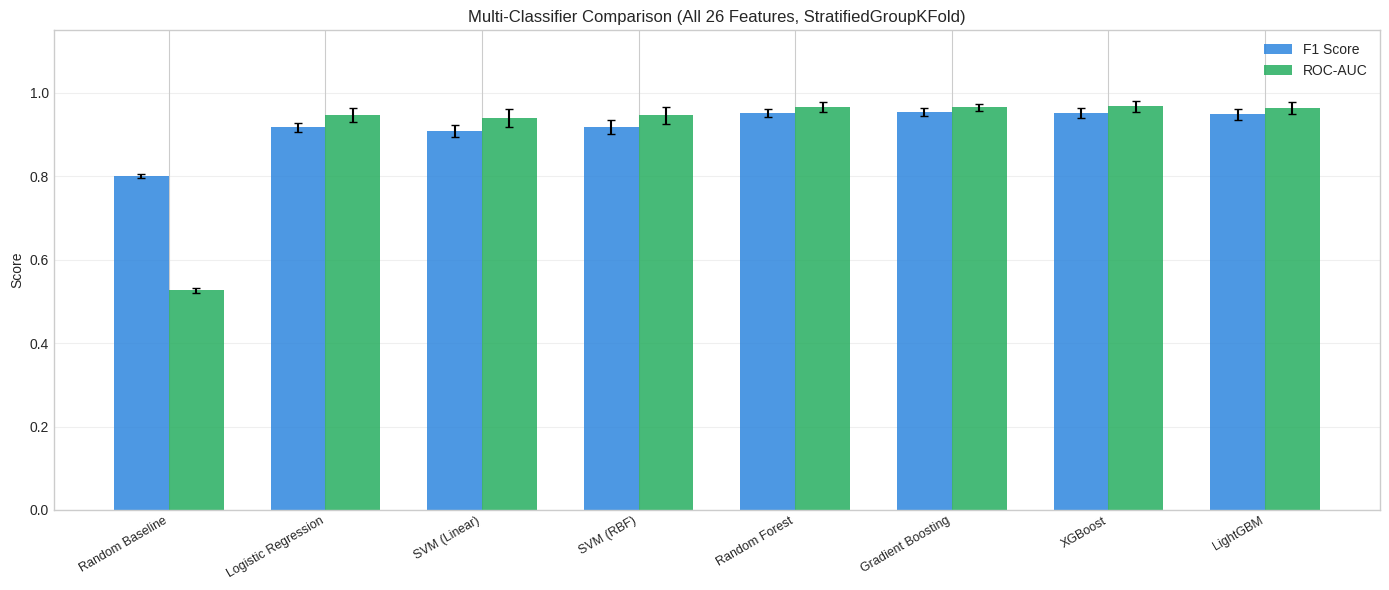

  Saved: fig_roc_curves.pdf, fig_roc_curves.png


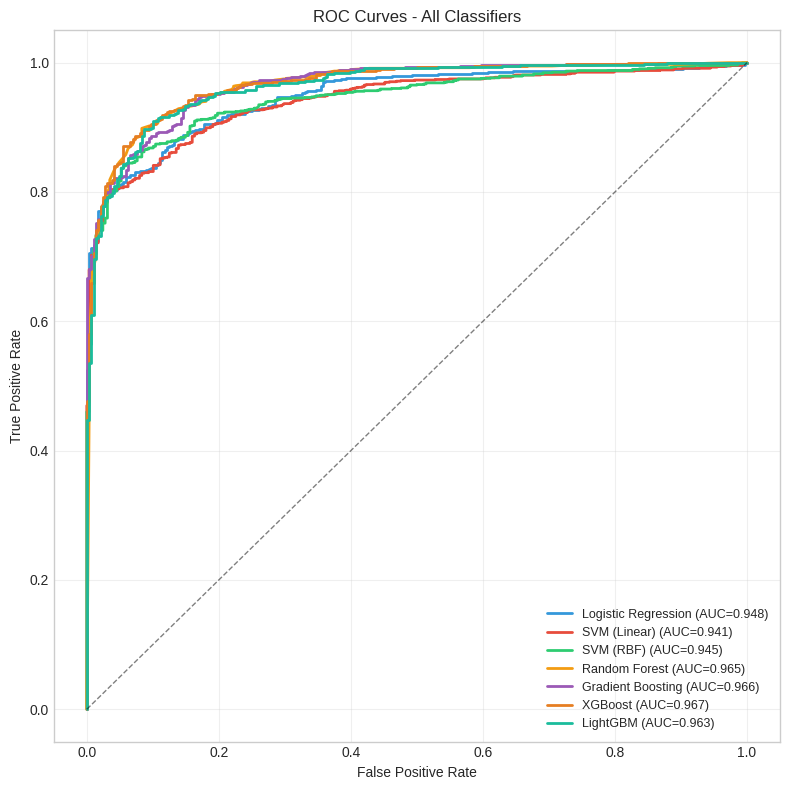

  Saved: fig_feature_importance.pdf, fig_feature_importance.png


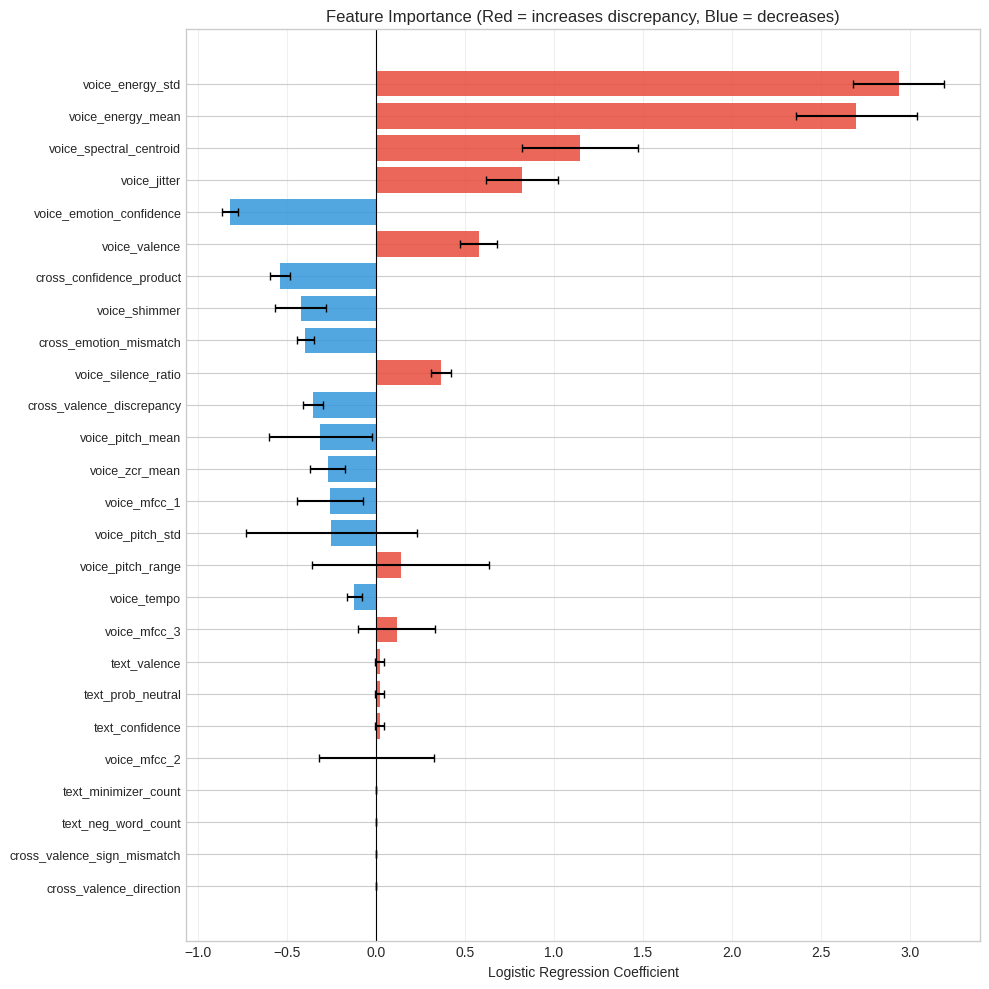

  Saved: fig_selection.pdf, fig_selection.png


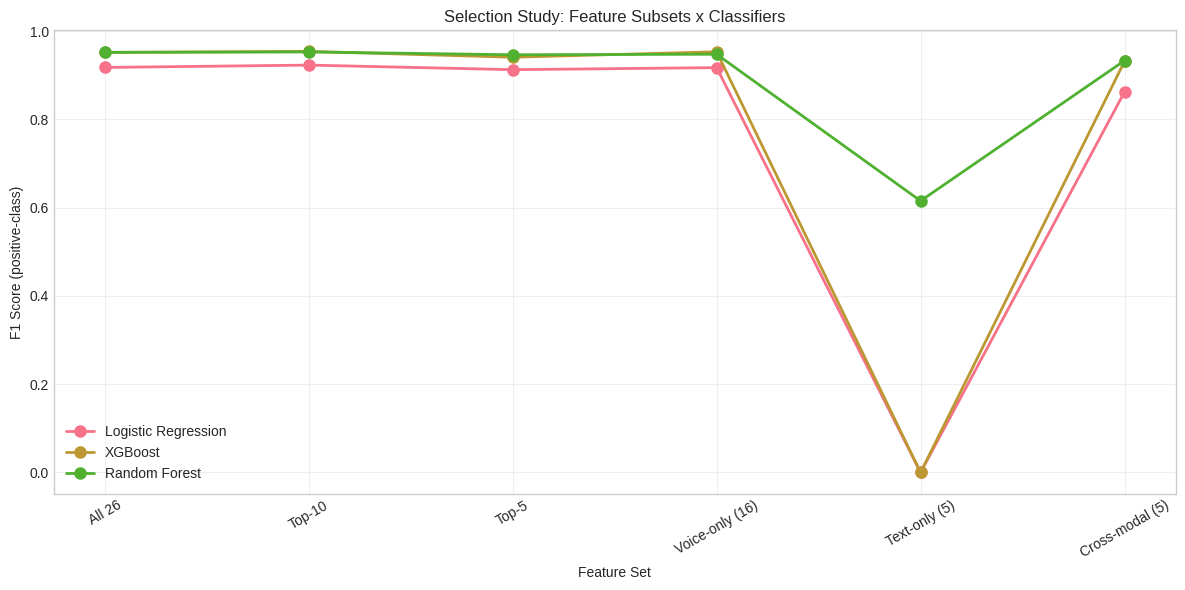

  Saved: fig_per_emotion.pdf, fig_per_emotion.png


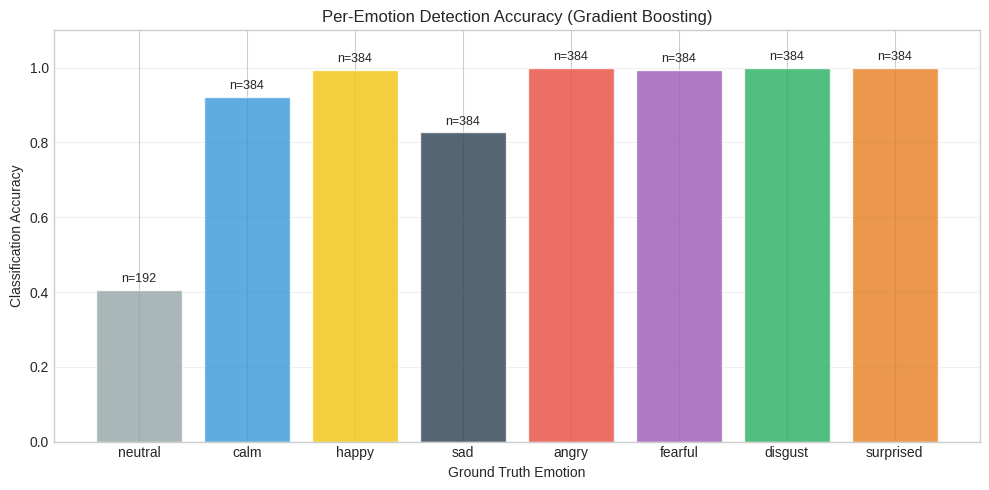

  Saved: fig_confusion_matrix.pdf, fig_confusion_matrix.png


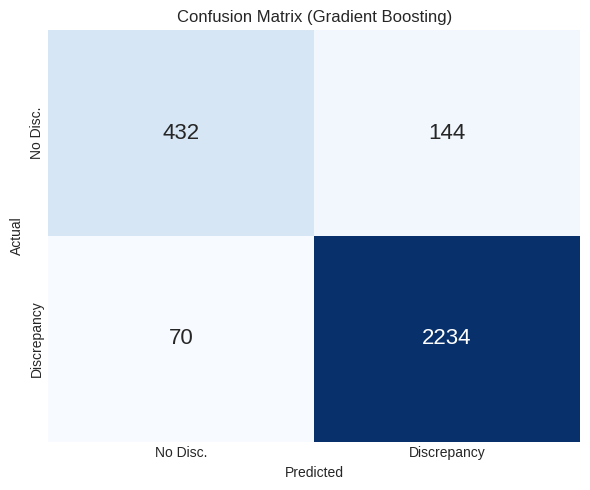

  Saved: fig_cross_modal_contribution.pdf, fig_cross_modal_contribution.png


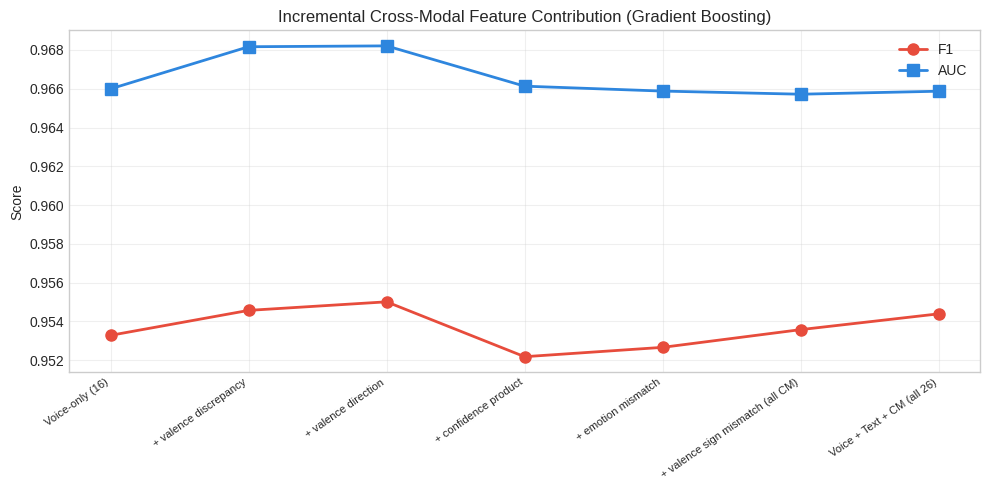


All figures saved.


In [17]:
print("=" * 70)
print("Generating Figures (PDF + PNG)")
print("=" * 70)

def save_fig(fig, name):
    fig.savefig(f'{name}.pdf', format='pdf', bbox_inches='tight')
    fig.savefig(f'{name}.png', dpi=300, bbox_inches='tight')
    print(f"  Saved: {name}.pdf, {name}.png")

# Figure 1: Multi-classifier comparison
fig, ax = plt.subplots(figsize=(14, 6))
model_names = list(all_results.keys())
f1_means = [pd.DataFrame(all_results[m])['f1'].mean() for m in model_names]
f1_stds = [pd.DataFrame(all_results[m])['f1'].std() for m in model_names]
auc_means = [pd.DataFrame(all_results[m])['roc_auc'].mean() for m in model_names]
auc_stds = [pd.DataFrame(all_results[m])['roc_auc'].std() for m in model_names]

x = np.arange(len(model_names))
width = 0.35
bars1 = ax.bar(x - width/2, f1_means, width, yerr=f1_stds, label='F1 Score', capsize=3, color='#2E86DE', alpha=0.85)
bars2 = ax.bar(x + width/2, auc_means, width, yerr=auc_stds, label='ROC-AUC', capsize=3, color='#27ae60', alpha=0.85)
ax.set_ylabel('Score')
ax.set_title('Multi-Classifier Comparison (All 26 Features, StratifiedGroupKFold)')
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=30, ha='right', fontsize=9)
ax.legend()
ax.set_ylim(0, 1.15)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
save_fig(fig, 'fig_classifier_comparison')
plt.show()

# Figure 2: ROC Curves (top classifiers)
fig, ax = plt.subplots(figsize=(8, 8))
colors = ['#95a5a6', '#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6', '#e67e22', '#1abc9c']
for i, (name, probs) in enumerate(all_probabilities.items()):
    if name == 'Random Baseline':
        continue
    fpr, tpr, _ = roc_curve(y, probs)
    auc_val = roc_auc_score(y, probs)
    ax.plot(fpr, tpr, color=colors[i % len(colors)], lw=2,
            label=f'{name} (AUC={auc_val:.3f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves - All Classifiers')
ax.legend(loc='lower right', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
save_fig(fig, 'fig_roc_curves')
plt.show()

# Figure 3: Feature Importance (LR)
if lr_imps:
    feat_imp_sorted = feat_imp.sort_values('Abs_Coefficient', ascending=True)
    colors_fi = ['#e74c3c' if c > 0 else '#3498db' for c in feat_imp_sorted['Coefficient']]

    fig, ax = plt.subplots(figsize=(10, 10))
    ax.barh(range(len(feat_imp_sorted)), feat_imp_sorted['Coefficient'],
            xerr=feat_imp_sorted['Std'], capsize=3, color=colors_fi, alpha=0.85)
    ax.set_yticks(range(len(feat_imp_sorted)))
    ax.set_yticklabels(feat_imp_sorted['Feature'], fontsize=9)
    ax.set_xlabel('Logistic Regression Coefficient')
    ax.set_title('Feature Importance (Red = increases discrepancy, Blue = decreases)')
    ax.axvline(x=0, color='black', linewidth=0.8)
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    save_fig(fig, 'fig_feature_importance')
    plt.show()

# Figure 4: Selection Study
fig, ax = plt.subplots(figsize=(12, 6))
for clf_name in selection_classifiers:
    subset = selection_df[selection_df['Classifier'] == clf_name]
    ax.plot(subset['Features'], subset['F1_mean'], 'o-', label=clf_name, linewidth=2, markersize=8)
ax.set_xlabel('Feature Set')
ax.set_ylabel('F1 Score (positive-class)')
ax.set_title('Selection Study: Feature Subsets x Classifiers')
ax.legend()
ax.tick_params(axis='x', rotation=30)
ax.grid(alpha=0.3)
plt.tight_layout()
save_fig(fig, 'fig_selection')
plt.show()

# Figure 5: Per-Emotion Analysis
fig, ax = plt.subplots(figsize=(10, 5))
emotion_colors = {
    'neutral': '#95a5a6', 'calm': '#3498db', 'happy': '#f1c40f',
    'sad': '#2c3e50', 'angry': '#e74c3c', 'fearful': '#9b59b6',
    'disgust': '#27ae60', 'surprised': '#e67e22'
}
bars = ax.bar(emotion_df['Emotion'], emotion_df['Accuracy'],
              color=[emotion_colors.get(e, '#ccc') for e in emotion_df['Emotion']],
              alpha=0.8, edgecolor='white')
for bar, row in zip(bars, emotion_df.itertuples()):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
            f'n={row.Count}', ha='center', fontsize=9)
ax.set_xlabel('Ground Truth Emotion')
ax.set_ylabel('Classification Accuracy')
ax.set_title(f'Per-Emotion Detection Accuracy ({best_name})')
ax.set_ylim(0, 1.1)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
save_fig(fig, 'fig_per_emotion')
plt.show()

# Figure 6: Confusion Matrix (Best Model)
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y, best_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['No Disc.', 'Discrepancy'],
            yticklabels=['No Disc.', 'Discrepancy'],
            cbar=False, annot_kws={'size': 16})
ax.set_title(f'Confusion Matrix ({best_name})')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
save_fig(fig, 'fig_confusion_matrix')
plt.show()

# Figure 7: Cross-Modal Incremental Contribution
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(len(inc_df)), inc_df['F1_mean'], 'o-', color='#e74c3c', linewidth=2, markersize=8, label='F1')
ax.plot(range(len(inc_df)), inc_df['AUC_mean'], 's-', color='#2E86DE', linewidth=2, markersize=8, label='AUC')
ax.set_xticks(range(len(inc_df)))
ax.set_xticklabels(inc_df['Configuration'], rotation=35, ha='right', fontsize=8)
ax.set_ylabel('Score')
ax.set_title(f'Incremental Cross-Modal Feature Contribution ({best_name})')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
save_fig(fig, 'fig_cross_modal_contribution')
plt.show()

print("\nAll figures saved.")

## 17: Key Numbers Summary

In [18]:
print("\n" + "=" * 70)
print("KEY NUMBERS FOR PAPER")
print("=" * 70)

print(f"\nDATASET:")
print(f"  Total samples: {len(df)}")
print(f"  Actors: {df['actor_id'].nunique()}")
print(f"  Emotions: {df['emotion_label'].nunique()}")
print(f"  Discrepancy: {(df['discrepancy'] == 1).sum()} | Non-discrepancy: {(df['discrepancy'] == 0).sum()}")
print(f"  Positive class ratio: {df['discrepancy'].mean():.1%}")
print(f"  Gender: {df['gender'].value_counts().to_dict()}")

print(f"\nMULTI-CLASSIFIER RESULTS (per-fold mean +/- std, 5-fold):")
for name, metrics in all_results.items():
    mdf = pd.DataFrame(metrics)
    print(f"  {name}:")
    print(f"    F1:   {mdf['f1'].mean():.4f} +/- {mdf['f1'].std():.4f}")
    print(f"    AUC:  {mdf['roc_auc'].mean():.4f} +/- {mdf['roc_auc'].std():.4f}")
    print(f"    Acc:  {mdf['accuracy'].mean():.4f} +/- {mdf['accuracy'].std():.4f}")
    print(f"    Prec: {mdf['precision'].mean():.4f} +/- {mdf['precision'].std():.4f}")
    print(f"    Rec:  {mdf['recall'].mean():.4f} +/- {mdf['recall'].std():.4f}")

print(f"\nOOF RESULTS (single score over all samples):")
print(oof_summary_df.to_string(index=False))

print(f"\nSELECTION STUDY:")
print(selection_df[['Classifier', 'Features', 'F1', 'AUC']].to_string(index=False))

print(f"\nCROSS-MODAL CONTRIBUTION:")
print(inc_df[['Configuration', 'Num_Features', 'F1', 'AUC']].to_string(index=False))

print(f"\nPER-EMOTION ANALYSIS:")
print(emotion_df.to_string(index=False))

print(f"\nFEATURE IMPORTANCE (LR, top 10):")
if lr_imps:
    for _, row in feat_imp.head(10).iterrows():
        d = "+" if row['Coefficient'] > 0 else "-"
        print(f"  {d} {row['Feature']}: {row['Coefficient']:.4f} +/- {row['Std']:.4f}")

print(f"\nTEXT PIPELINE:")
for stmt in unique_statements:
    tf = text_features_cache[stmt]
    print(f"  \"{stmt}\"")
    print(f"    Predicted: {tf['text_pred_emotion']} (conf: {tf['text_confidence']:.4f}, valence: {tf['text_valence']:.4f})")

print(f"\nVALENCE MAPPING:")
print(f"  Text: {TEXT_EMOTION_VALENCE}")
print(f"  Voice: {VOICE_EMOTION_VALENCE}")

print(f"\nFIGURES GENERATED:")
figs = [
    'fig_classifier_comparison', 'fig_roc_curves', 'fig_feature_importance',
    'fig_selection', 'fig_per_emotion', 'fig_confusion_matrix',
    'fig_cross_modal_contribution', 'fig_pipeline_z'
]
for f in figs:
    print(f"  {f}.pdf/.png")


KEY NUMBERS FOR PAPER

DATASET:
  Total samples: 2880
  Actors: 24
  Emotions: 8
  Discrepancy: 2304 | Non-discrepancy: 576
  Positive class ratio: 80.0%
  Gender: {'male': 1440, 'female': 1440}

MULTI-CLASSIFIER RESULTS (per-fold mean +/- std, 5-fold):
  Random Baseline:
    F1:   0.8017 +/- 0.0046
    AUC:  0.5267 +/- 0.0062
    Acc:  0.6863 +/- 0.0065
    Prec: 0.8109 +/- 0.0024
    Rec:  0.7926 +/- 0.0068
  Logistic Regression:
    F1:   0.9178 +/- 0.0110
    AUC:  0.9471 +/- 0.0166
    Acc:  0.8747 +/- 0.0161
    Prec: 0.9644 +/- 0.0133
    Rec:  0.8758 +/- 0.0194
  SVM (Linear):
    F1:   0.9076 +/- 0.0143
    AUC:  0.9404 +/- 0.0219
    Acc:  0.8607 +/- 0.0217
    Prec: 0.9665 +/- 0.0175
    Rec:  0.8556 +/- 0.0144
  SVM (RBF):
    F1:   0.9173 +/- 0.0169
    AUC:  0.9460 +/- 0.0201
    Acc:  0.8748 +/- 0.0250
    Prec: 0.9727 +/- 0.0190
    Rec:  0.8681 +/- 0.0244
  Random Forest:
    F1:   0.9520 +/- 0.0100
    AUC:  0.9660 +/- 0.0117
    Acc:  0.9217 +/- 0.0165
    Prec: 0.9

## 18: Save All Results to CSV

In [19]:
print("Saving results...")

# Multi-classifier per-fold results
rows = []
for name, metrics in all_results.items():
    for m in metrics:
        row = {'model': name}
        for k, v in m.items():
            if isinstance(v, (int, float, np.floating, np.integer)):
                row[k] = v
        rows.append(row)
pd.DataFrame(rows).to_csv('multi_classifier_results.csv', index=False)

# OOF summary (already saved in Cell 8, re-save here for completeness)
oof_summary_df.to_csv('oof_summary.csv', index=False)
oof_pred_df.to_csv('oof_predictions.csv', index=False)

# Selection
selection_df.to_csv('selection_results.csv', index=False)

# Per-emotion
emotion_df.to_csv('per_emotion_analysis.csv', index=False)

# Cross-modal contribution
inc_df.to_csv('cross_modal_contribution.csv', index=False)

# Feature importance
if lr_imps:
    feat_imp.to_csv('feature_importance.csv', index=False)

# Full dataset with features
df.to_csv('full_feature_dataset.csv', index=False)

print("\nAll files saved:")
print("  multi_classifier_results.csv  -- per-fold breakdown")
print("  oof_summary.csv               -- OOF scores per model")
print("  oof_predictions.csv           -- per-sample OOF predictions")
print("  selection_results.csv")
print("  per_emotion_analysis.csv")
print("  cross_modal_contribution.csv")
print("  feature_importance.csv")
print("  full_feature_dataset.csv")

print("\n" + "=" * 70)
print("NOTEBOOK COMPLETE")
print("=" * 70)

Saving results...

All files saved:
  multi_classifier_results.csv  -- per-fold breakdown
  oof_summary.csv               -- OOF scores per model
  oof_predictions.csv           -- per-sample OOF predictions
  selection_results.csv
  per_emotion_analysis.csv
  cross_modal_contribution.csv
  feature_importance.csv
  full_feature_dataset.csv

NOTEBOOK COMPLETE


## MELD VALIDATION CELLS

> Requires: Your saved MELD preprocessed dataset added as Kaggle input.  
> Reuses: models + functions from Cells 2-7 (text_model, ser_model,
>        extract_text_features, extract_prosodic_features,
>         extract_voice_emotion, evaluate_model, save_fig, etc.)

## 19: Load Preprocessed MELD

In [20]:
print("=" * 70)
print("MELD VALIDATION: Loading Preprocessed Dataset")
print("=" * 70)

meld_prep = "/kaggle/input/datasets/kaunghsethein/meld-prepared-audio/meld_prepared"

print(f"MELD preprocessed path: {meld_prep}")

# Load metadata
df_meld = pd.read_csv(os.path.join(meld_prep, 'meld_metadata.csv'))
df_meld['audio_path'] = df_meld['wav_file'].apply(
    lambda x: os.path.join(meld_prep, x))

# Verify audio files exist
df_meld['audio_exists'] = df_meld['audio_path'].apply(os.path.exists)
print(f"Total entries: {len(df_meld)}")
print(f"Audio found:   {df_meld['audio_exists'].sum()}")
df_meld = df_meld[df_meld['audio_exists']].reset_index(drop=True)

print(f"\nSplit distribution:")
print(df_meld['split'].value_counts().to_string())
print(f"\nEmotion distribution:")
print(df_meld['emotion'].value_counts().to_string())

MELD VALIDATION: Loading Preprocessed Dataset
MELD preprocessed path: /kaggle/input/datasets/kaunghsethein/meld-prepared-audio/meld_prepared
Total entries: 13706
Audio found:   13706

Split distribution:
split
train    9988
test     2610
dev      1108

Emotion distribution:
emotion
neutral     6434
joy         2308
surprise    1636
anger       1607
sadness     1002
disgust      361
fear         358


## 20: MELD Feature Extraction

In [21]:
print("\n" + "=" * 70)
print("MELD VALIDATION: Feature Extraction")
print("=" * 70)

# --- Text features ---
print("Text features...")
unique_texts = df_meld['utterance_text'].dropna().unique()
print(f"  Unique texts: {len(unique_texts)}")

meld_text_cache = {}
for txt in tqdm(unique_texts, desc="Text"):
    t = str(txt).strip()
    if t == '' or t == 'nan':
        meld_text_cache[txt] = {
            'text_pred_emotion': 'neutral', 'text_confidence': 1.0,
            'text_valence': 0.0, 'text_neg_word_count': 0,
            'text_minimizer_count': 0, 'text_prob_neutral': 1.0}
    else:
        meld_text_cache[txt] = extract_text_features(t)

for col in ['text_pred_emotion', 'text_confidence', 'text_valence',
            'text_neg_word_count', 'text_minimizer_count', 'text_prob_neutral']:
    df_meld[col] = df_meld['utterance_text'].map(
        lambda x: meld_text_cache.get(x, {}).get(col, 0))

print(f"  Text pred distribution: {df_meld['text_pred_emotion'].value_counts().to_dict()}")

# --- Prosodic features ---
print("\nProsodic features...")
pros_list = []
for _, row in tqdm(df_meld.iterrows(), total=len(df_meld), desc="Prosody"):
    feats = extract_prosodic_features(row['audio_path'])
    pros_list.append(feats if feats else {})

pros_df = pd.DataFrame(pros_list)
df_meld = pd.concat([df_meld.reset_index(drop=True), pros_df], axis=1)
df_meld = df_meld.dropna(subset=['voice_pitch_mean']).reset_index(drop=True)
print(f"  After prosody: {len(df_meld)} samples")

# --- Voice SER ---
print("\nVoice SER...")
ve_list = []
for _, row in tqdm(df_meld.iterrows(), total=len(df_meld), desc="SER"):
    ve_list.append(extract_voice_emotion(row['audio_path']))

ve_df = pd.DataFrame(ve_list)
df_meld = pd.concat([df_meld.reset_index(drop=True), ve_df.reset_index(drop=True)], axis=1)
print(f"  Voice SER distribution: {df_meld['voice_pred_emotion'].value_counts().to_dict()}")

# --- Cross-modal features ---
df_meld['cross_valence_discrepancy'] = np.abs(df_meld['text_valence'] - df_meld['voice_valence'])
df_meld['cross_valence_direction'] = np.sign(df_meld['voice_valence'] - df_meld['text_valence']).astype(int)
df_meld['cross_confidence_product'] = df_meld['text_confidence'] * df_meld['voice_emotion_confidence']
df_meld['cross_emotion_mismatch'] = (df_meld['text_pred_emotion'] != df_meld['voice_pred_emotion']).astype(int)
df_meld['cross_valence_sign_mismatch'] = (np.sign(df_meld['text_valence']) != np.sign(df_meld['voice_valence'])).astype(int)

# --- Discrepancy label ---
# text conceals = DistilRoBERTa text prediction != ground truth emotion
df_meld['discrepancy'] = (df_meld['text_pred_emotion'] != df_meld['emotion']).astype(int)

print(f"\nDiscrepancy label:")
print(f"  Text reveals (0): {(df_meld['discrepancy'] == 0).sum()}")
print(f"  Text conceals (1): {(df_meld['discrepancy'] == 1).sum()}")
print(f"  Rate: {df_meld['discrepancy'].mean():.1%}")

# KEY STAT: text valence variance
print(f"\nText valence std  MELD: {df_meld['text_valence'].std():.4f}")
print(f"Text valence std  RAVDESS: {df['text_valence'].std():.4f}")

# Save features
df_meld.to_csv('meld_features.csv', index=False)
print("Saved: meld_features.csv")


MELD VALIDATION: Feature Extraction
Text features...
  Unique texts: 12158


Text: 100%|██████████| 12158/12158 [01:00<00:00, 199.75it/s]


  Text pred distribution: {'neutral': 4477, 'surprise': 3314, 'anger': 2021, 'joy': 1689, 'disgust': 1082, 'fear': 563, 'sadness': 560}

Prosodic features...


Prosody: 100%|██████████| 13706/13706 [1:49:51<00:00,  2.08it/s]


  After prosody: 13079 samples

Voice SER...


SER: 100%|██████████| 13079/13079 [13:43<00:00, 15.88it/s]


  Voice SER distribution: {'fearful': 4118, 'happy': 3482, 'calm': 2023, 'sad': 1503, 'neutral': 864, 'disgust': 624, 'angry': 465}

Discrepancy label:
  Text reveals (0): 6697
  Text conceals (1): 6382
  Rate: 48.8%

Text valence std  MELD: 0.3912
Text valence std  RAVDESS: 0.0187
Saved: meld_features.csv


## 21: MELD Classification & Selection

In [22]:
print("\n" + "=" * 70)
print("MELD VALIDATION: Classification & Selection")
print("=" * 70)

# Standard MELD split
meld_train = df_meld[df_meld['split'].isin(['train', 'dev'])].reset_index(drop=True)
meld_test = df_meld[df_meld['split'] == 'test'].reset_index(drop=True)

X_m_train = meld_train[ALL_FEATURES].values
X_m_test = meld_test[ALL_FEATURES].values
y_m_train = meld_train['discrepancy'].values
y_m_test = meld_test['discrepancy'].values

print(f"Train: {len(meld_train)} (disc rate {y_m_train.mean():.1%})")
print(f"Test:  {len(meld_test)} (disc rate {y_m_test.mean():.1%})")

def eval_meld(feat_list, clf_template):
    fidx = [ALL_FEATURES.index(f) for f in feat_list]
    scaler = StandardScaler()
    Xtr = scaler.fit_transform(X_m_train[:, fidx])
    Xte = scaler.transform(X_m_test[:, fidx])
    from sklearn.base import clone
    clf = clone(clf_template)
    clf.fit(Xtr, y_m_train)
    yp = clf.predict(Xte)
    yprob = clf.predict_proba(Xte)[:, 1] if hasattr(clf, 'predict_proba') else np.zeros(len(y_m_test))
    return {
        'f1': f1_score(y_m_test, yp, zero_division=0),
        'precision': precision_score(y_m_test, yp, zero_division=0),
        'recall': recall_score(y_m_test, yp, zero_division=0),
        'accuracy': accuracy_score(y_m_test, yp),
        'roc_auc': roc_auc_score(y_m_test, yprob) if len(np.unique(y_m_test)) > 1 else 0.5,
    }

meld_clfs = {
    'LR': LogisticRegression(C=1.0, class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=RANDOM_STATE),
    'XGBoost': xgb.XGBClassifier(n_estimators=100, scale_pos_weight=(y_m_train==0).sum()/(y_m_train==1).sum(),
                                  random_state=RANDOM_STATE, eval_metric='logloss', verbosity=0),
    'Random Forest': RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1),
}

# Feature configs for selection
meld_feat_configs = {
    'Text only (5)':            TEXT_FEATURES,
    'Voice only (16)':          VOICE_FEATURES,
    'Cross-modal only (5)':     CROSS_MODAL_FEATURES,
    'Voice + Cross-modal (21)': VOICE_FEATURES + CROSS_MODAL_FEATURES,
    'All 26':                   ALL_FEATURES,
}

# Run selection
meld_results = []
for clf_name, clf in meld_clfs.items():
    for feat_name, feat_list in meld_feat_configs.items():
        res = eval_meld(feat_list, clf)
        meld_results.append({
            'Classifier': clf_name, 'Features': feat_name,
            'F1': res['f1'], 'AUC': res['roc_auc'], 'Acc': res['accuracy'],
        })
        print(f"  {clf_name:<20} {feat_name:<25} F1={res['f1']:.4f} AUC={res['roc_auc']:.4f}")

meld_abl_df = pd.DataFrame(meld_results)


MELD VALIDATION: Classification & Selection
Train: 10594 (disc rate 47.9%)
Test:  2485 (disc rate 52.4%)
  LR                   Text only (5)             F1=0.7067 AUC=0.7420
  LR                   Voice only (16)           F1=0.5328 AUC=0.5366
  LR                   Cross-modal only (5)      F1=0.6387 AUC=0.6870
  LR                   Voice + Cross-modal (21)  F1=0.6385 AUC=0.6868
  LR                   All 26                    F1=0.7190 AUC=0.7480
  Gradient Boosting    Text only (5)             F1=0.7468 AUC=0.7915
  Gradient Boosting    Voice only (16)           F1=0.4565 AUC=0.5258
  Gradient Boosting    Cross-modal only (5)      F1=0.6695 AUC=0.7172
  Gradient Boosting    Voice + Cross-modal (21)  F1=0.6641 AUC=0.7195
  Gradient Boosting    All 26                    F1=0.7457 AUC=0.7890
  XGBoost              Text only (5)             F1=0.7244 AUC=0.7785
  XGBoost              Voice only (16)           F1=0.5277 AUC=0.5347
  XGBoost              Cross-modal only (5)      F1=0.

## 22: Cross-Modal Delta Comparison (RAVDESS vs MELD)

In [23]:
print("\n" + "=" * 70)
print("KEY RESULT: Cross-Modal Delta (RAVDESS vs MELD)")
print("=" * 70)

# For each classifier:
#   delta = F1(voice+cross-modal) - F1(voice-only)
# Compare across datasets.

ravdess_clfs = {
    'LR': LogisticRegression(C=1.0, class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=RANDOM_STATE),
    'XGBoost': xgb.XGBClassifier(n_estimators=100, scale_pos_weight=(y==0).sum()/(y==1).sum(),
                                  random_state=RANDOM_STATE, eval_metric='logloss', verbosity=0),
    'Random Forest': RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1),
}

comp_rows = []
for clf_name in meld_clfs:
    # MELD
    m_vo = meld_abl_df[(meld_abl_df['Classifier']==clf_name) & (meld_abl_df['Features']=='Voice only (16)')]['F1'].values[0]
    m_vcm = meld_abl_df[(meld_abl_df['Classifier']==clf_name) & (meld_abl_df['Features']=='Voice + Cross-modal (21)')]['F1'].values[0]
    m_all = meld_abl_df[(meld_abl_df['Classifier']==clf_name) & (meld_abl_df['Features']=='All 26')]['F1'].values[0]

    # RAVDESS (re-run for clean numbers)
    rav_clf = ravdess_clfs[clf_name]
    r_vo_m, _, _, _ = evaluate_model(VOICE_FEATURES, rav_clf, X, y, groups, gender_labels)
    r_vcm_m, _, _, _ = evaluate_model(VOICE_FEATURES + CROSS_MODAL_FEATURES, rav_clf, X, y, groups, gender_labels)
    r_all_m, _, _, _ = evaluate_model(ALL_FEATURES, rav_clf, X, y, groups, gender_labels)

    r_vo = pd.DataFrame(r_vo_m)['f1'].mean()
    r_vcm = pd.DataFrame(r_vcm_m)['f1'].mean()
    r_all = pd.DataFrame(r_all_m)['f1'].mean()

    comp_rows.append({
        'Classifier': clf_name,
        'R_vo': r_vo, 'R_vcm': r_vcm, 'R_all': r_all, 'R_delta': r_vcm - r_vo,
        'M_vo': m_vo, 'M_vcm': m_vcm, 'M_all': m_all, 'M_delta': m_vcm - m_vo,
    })

comp_df = pd.DataFrame(comp_rows)

print(f"\n{'Classifier':<20} {'--- RAVDESS ---':>25} {'--- MELD ---':>25}")
print(f"{'':20} {'Voice':>8} {'V+CM':>8} {'delta':>8} {'Voice':>8} {'V+CM':>8} {'delta':>8}")
print("=" * 80)
for _, r in comp_df.iterrows():
    print(f"{r['Classifier']:<20} "
          f"{r['R_vo']:>8.4f} {r['R_vcm']:>8.4f} {r['R_delta']:>+8.4f} "
          f"{r['M_vo']:>8.4f} {r['M_vcm']:>8.4f} {r['M_delta']:>+8.4f}")

print(f"\nMean delta  RAVDESS: {comp_df['R_delta'].mean():+.4f}")
print(f"Mean delta  MELD:    {comp_df['M_delta'].mean():+.4f}")

comp_df.to_csv('crossmodal_delta_comparison.csv', index=False)
meld_abl_df.to_csv('meld_selection.csv', index=False)


KEY RESULT: Cross-Modal Delta (RAVDESS vs MELD)

Classifier                     --- RAVDESS ---              --- MELD ---
                        Voice     V+CM    delta    Voice     V+CM    delta
LR                     0.9174   0.9174  -0.0001   0.5328   0.6385  +0.1058
Gradient Boosting      0.9533   0.9536  +0.0003   0.4565   0.6641  +0.2076
XGBoost                0.9533   0.9520  -0.0014   0.5277   0.6531  +0.1255
Random Forest          0.9478   0.9509  +0.0032   0.4572   0.6570  +0.1999

Mean delta  RAVDESS: +0.0005
Mean delta  MELD:    +0.1597


## 23: Figures & Summary


Figures & Summary
  Saved: fig_crossmodal_delta.pdf, fig_crossmodal_delta.png


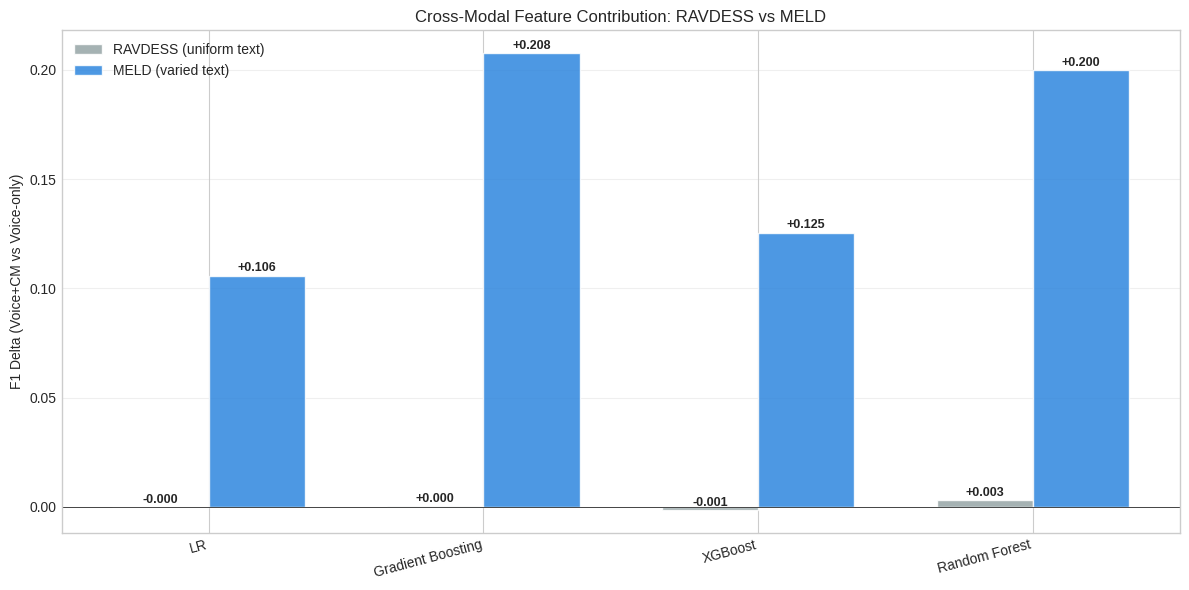

  Saved: fig_meld_selection.pdf, fig_meld_selection.png


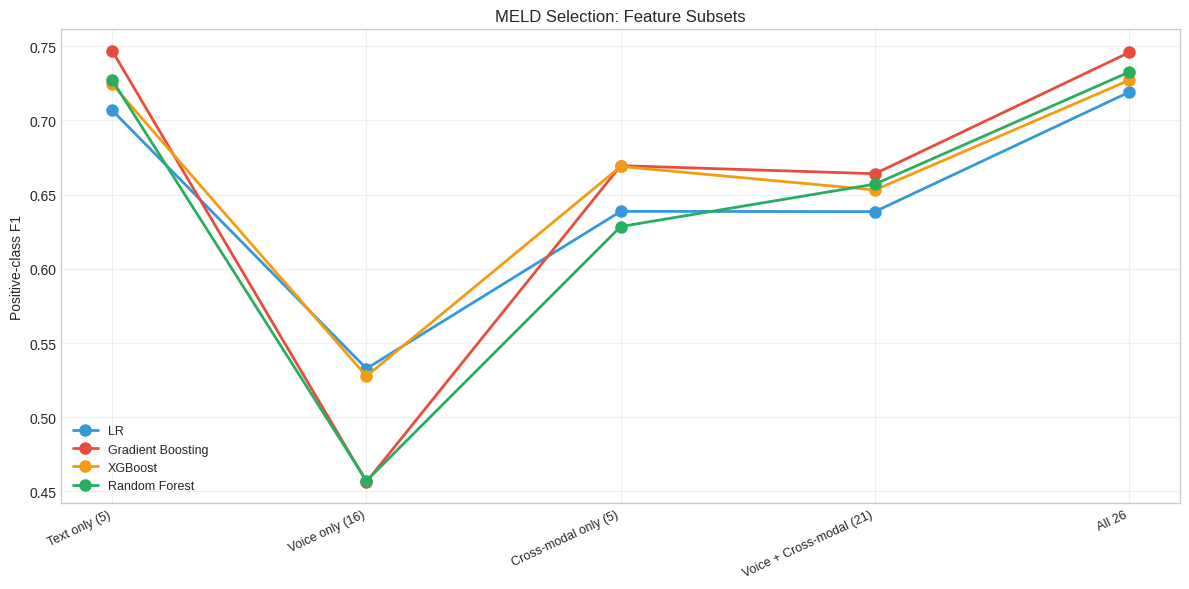


ALL NUMBERS FOR PAPER

MELD DATASET:
  Samples: 13079 (train+dev: 10594, test: 2485)
  Discrepancy rate: 48.8%
  Text valence std: 0.3912 (RAVDESS: 0.0187)

MELD SELECTION:
       Classifier                 Features       F1      AUC      Acc
               LR            Text only (5) 0.706716 0.742023 0.683702
               LR          Voice only (16) 0.532755 0.536570 0.523541
               LR     Cross-modal only (5) 0.638695 0.686960 0.625755
               LR Voice + Cross-modal (21) 0.638531 0.686831 0.627767
               LR                   All 26 0.719042 0.748038 0.697787
Gradient Boosting            Text only (5) 0.746831 0.791493 0.734809
Gradient Boosting          Voice only (16) 0.456473 0.525823 0.515091
Gradient Boosting     Cross-modal only (5) 0.669492 0.717169 0.654728
Gradient Boosting Voice + Cross-modal (21) 0.664069 0.719515 0.653119
Gradient Boosting                   All 26 0.745750 0.788996 0.735211
          XGBoost            Text only (5) 0.724354 0.77

In [24]:
print("\n" + "=" * 70)
print("Figures & Summary")
print("=" * 70)

# Figure: delta comparison
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(comp_df))
w = 0.35
ax.bar(x - w/2, comp_df['R_delta'], w, label='RAVDESS (uniform text)',
       color='#95a5a6', alpha=0.85, edgecolor='white')
ax.bar(x + w/2, comp_df['M_delta'], w, label='MELD (varied text)',
       color='#2E86DE', alpha=0.85, edgecolor='white')
for i, (_, r) in enumerate(comp_df.iterrows()):
    ax.text(i - w/2, r['R_delta'] + 0.002, f"{r['R_delta']:+.3f}",
            ha='center', fontsize=9, fontweight='bold')
    ax.text(i + w/2, r['M_delta'] + 0.002, f"{r['M_delta']:+.3f}",
            ha='center', fontsize=9, fontweight='bold')
ax.set_ylabel('F1 Delta (Voice+CM vs Voice-only)')
ax.set_title('Cross-Modal Feature Contribution: RAVDESS vs MELD')
ax.set_xticks(x)
ax.set_xticklabels(comp_df['Classifier'], rotation=15, ha='right')
ax.legend()
ax.axhline(y=0, color='black', linewidth=0.5)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
save_fig(fig, 'fig_crossmodal_delta')
plt.show()

# Figure: MELD selection
fig, ax = plt.subplots(figsize=(12, 6))
colors_c = {'LR': '#3498db', 'Gradient Boosting': '#e74c3c',
            'XGBoost': '#f39c12', 'Random Forest': '#27ae60'}
feat_order = list(meld_feat_configs.keys())
for clf_name in meld_clfs:
    vals = [meld_abl_df[(meld_abl_df['Classifier']==clf_name) &
                        (meld_abl_df['Features']==fn)]['F1'].values[0]
            for fn in feat_order]
    ax.plot(range(len(feat_order)), vals, 'o-', label=clf_name, linewidth=2,
            markersize=8, color=colors_c.get(clf_name, '#333'))
ax.set_xticks(range(len(feat_order)))
ax.set_xticklabels(feat_order, rotation=25, ha='right', fontsize=9)
ax.set_ylabel('Positive-class F1')
ax.set_title('MELD Selection: Feature Subsets')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
save_fig(fig, 'fig_meld_selection')
plt.show()

# --- FULL SUMMARY ---
print("\n" + "=" * 70)
print("ALL NUMBERS FOR PAPER")
print("=" * 70)

print(f"\nMELD DATASET:")
print(f"  Samples: {len(df_meld)} (train+dev: {len(meld_train)}, test: {len(meld_test)})")
print(f"  Discrepancy rate: {df_meld['discrepancy'].mean():.1%}")
print(f"  Text valence std: {df_meld['text_valence'].std():.4f} (RAVDESS: {df['text_valence'].std():.4f})")

print(f"\nMELD SELECTION:")
print(meld_abl_df.to_string(index=False))

print(f"\nCROSS-MODAL DELTA COMPARISON:")
print(comp_df.to_string(index=False))

print(f"\nMean cross-modal delta:")
print(f"  RAVDESS: {comp_df['R_delta'].mean():+.4f}")
print(f"  MELD:    {comp_df['M_delta'].mean():+.4f}")

print(f"\nFigures: fig_crossmodal_delta.pdf/.png, fig_meld_selection.pdf/.png")
print(f"CSVs: crossmodal_delta_comparison.csv, meld_selection.csv, meld_features.csv")